In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Cargar dataset
df = pd.read_csv("data.csv", sep=";")

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# Vista general
print("Dimensiones del dataset:", df.shape)
display(df.head())
print(df.info())

Dimensiones del dataset: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [5]:
# Valores nulos
print("Valores nulos por columna:")
display(df.isnull().sum())

# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:


,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


Filas duplicadas: 0


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


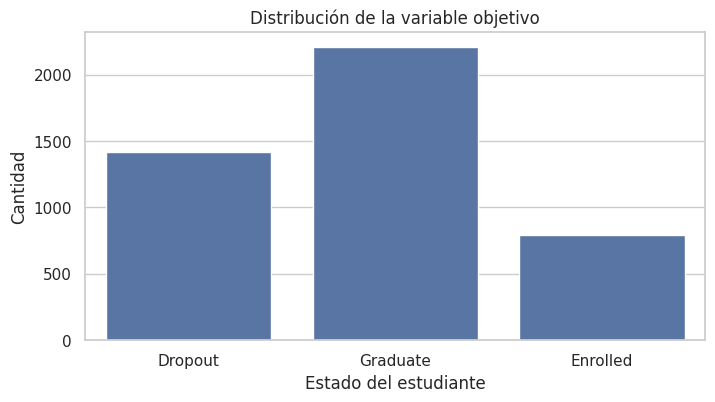

In [6]:
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True) * 100)

sns.countplot(data=df, x="Target")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Estado del estudiante")
plt.ylabel("Cantidad")
plt.show()

Se puede ver que el dataset está desbalanceado, por lo que probablemente, en las siguientes etapas, sean necerio aumentar los datos

In [7]:
# Estadísticos descriptivos de las variables numéricas
df.describe()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [8]:
num_cols = [
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)"
]

display(df[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Admission grade,4424.0,126.978119,14.482001,95.0,117.90,126.100000,134.800000,190.000000
Age at enrollment,4424.0,23.265145,7.587816,17.0,19.00,20.000000,25.000000,70.000000
Curricular units 1st sem (approved),4424.0,4.706600,3.094238,0.0,3.00,5.000000,6.000000,26.000000
Curricular units 1st sem (grade),4424.0,10.640822,4.843663,0.0,11.00,12.285714,13.400000,18.875000
Curricular units 2nd sem (approved),4424.0,4.435805,3.014764,0.0,2.00,5.000000,6.000000,20.000000
Curricular units 2nd sem (grade),4424.0,10.230206,5.210808,0.0,10.75,12.200000,13.333333,18.571429


En general, las variables académicas muestran una dispersión importante entre estudiantes.
Se observa que tanto en el primer como en el segundo semestre existen casos con rendimiento muy bajo,
reflejados en asignaturas aprobadas y notas iguales a 0.
Esto sugiere que el rendimiento académico es una variable importante para explicar diferencias en el estado final del estudiante.

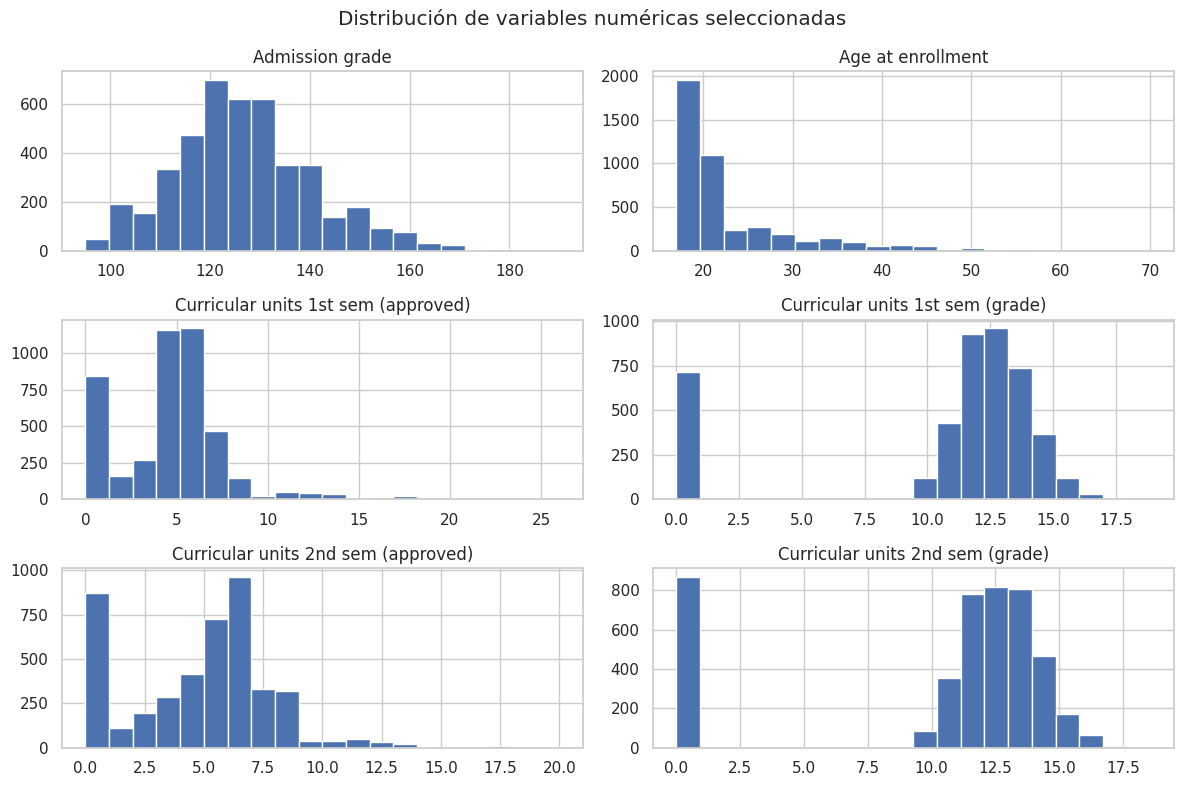

In [9]:
df[num_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribución de variables numéricas seleccionadas")
plt.tight_layout()
plt.show()

La calificación de admisión se concentra principalmente entre 115 y 135 puntos,mostrando una distribución relativamente centrada, sin una dispersión extrema.

La edad de matrícula se concentra principalmente en estudiantes jóvenes, aunque existen algunos casos de mayor edad, lo que genera una asimetría hacia la derecha.

En el primer semestre, la mayoría de los estudiantes aprobó entre 4 y 7 asignaturas. Sin embargo, también se observan varios casos con 0 aprobaciones, lo que podría asociarse a estudiantes con mayor riesgo académico.

En general, las variables académicas muestran una concentración en rangos intermedios, pero también revelan la existencia de un grupo de estudiantes con rendimiento nulo o muy bajo. Esto reafirma que el desempeño académico podría ser un factor importante para explicar el estado final del estudiante.

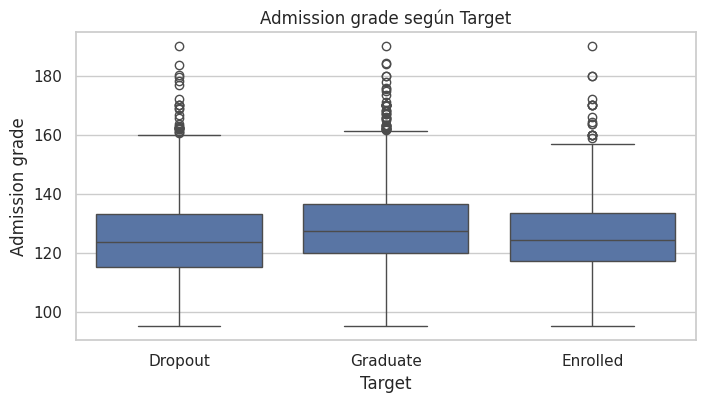

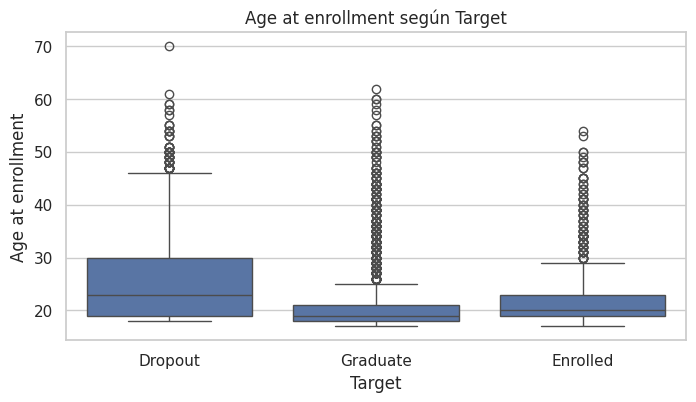

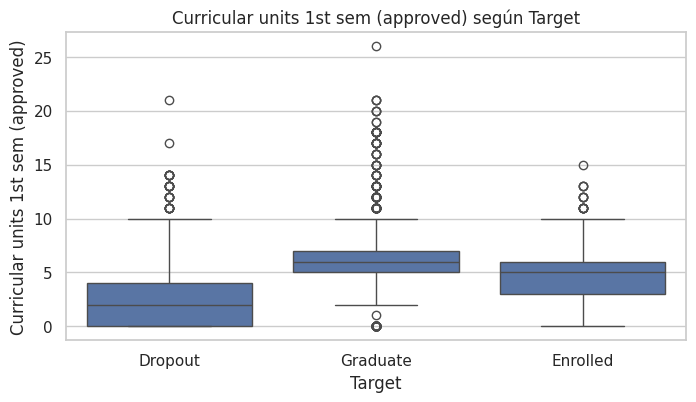

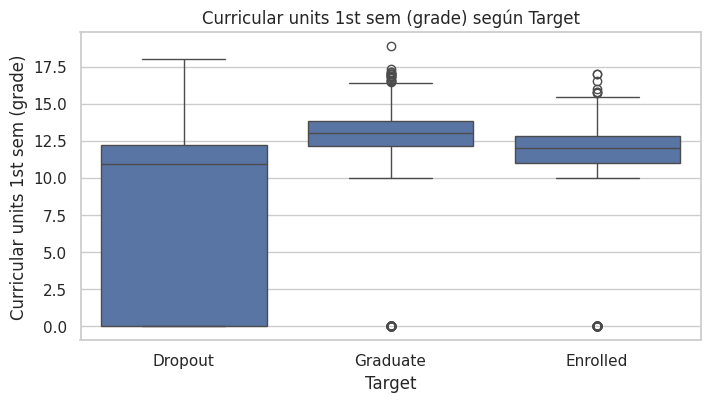

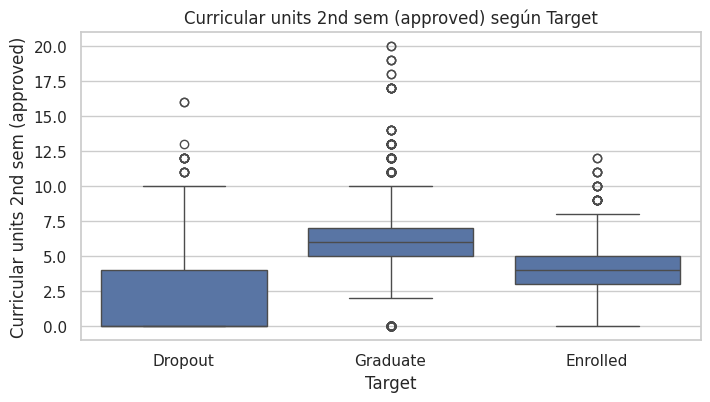

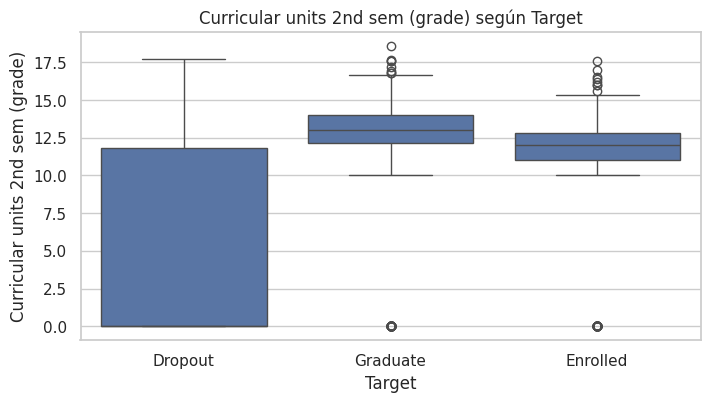

In [10]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="Target", y=col)
    plt.title(f"{col} según Target")
    plt.show()

Los boxplots muestran que las variables académicas del primer y segundo semestre diferencian claramente a los estudiantes según su estado final. En general, los graduados presentan mejores notas y más asignaturas aprobadas, los desertores muestran los resultados más bajos, y los estudiantes que continúan en carrera tienden a ubicarse en un nivel intermedio.

In [11]:
cat_cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Gender"
]

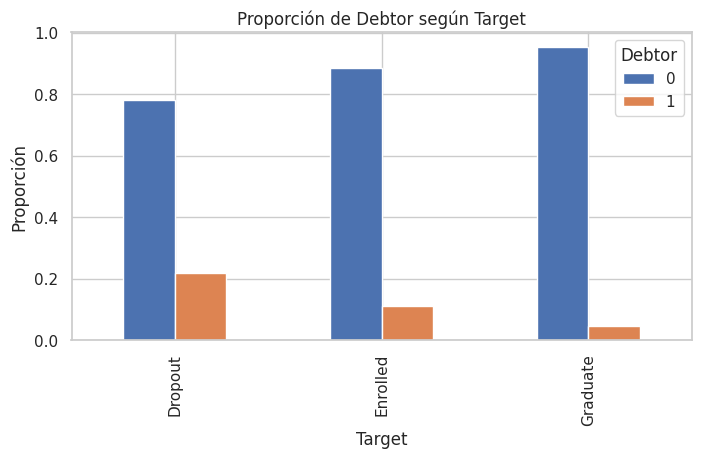

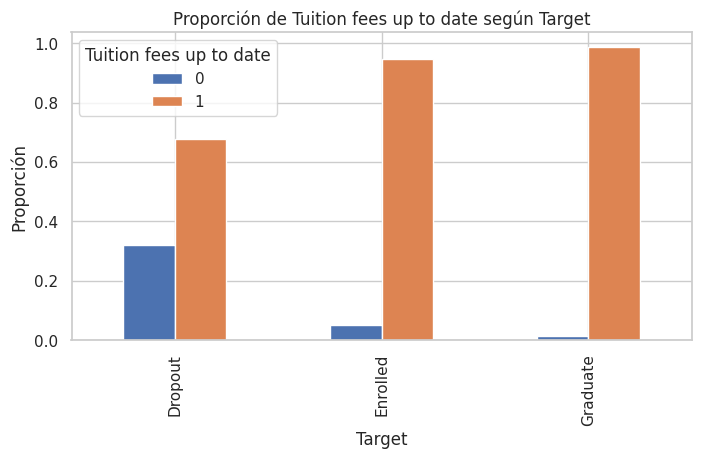

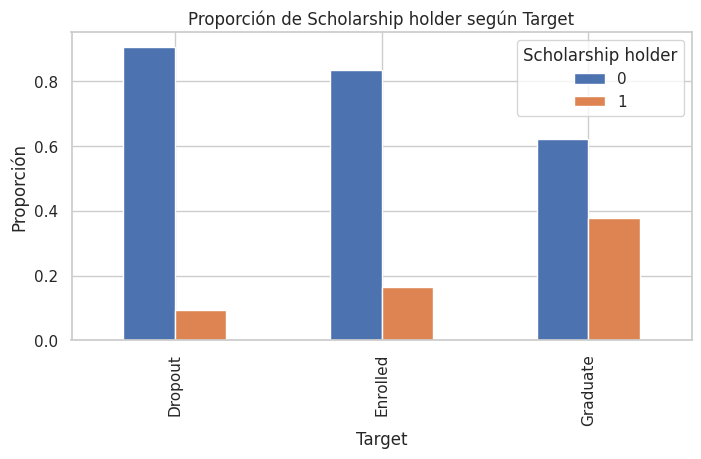

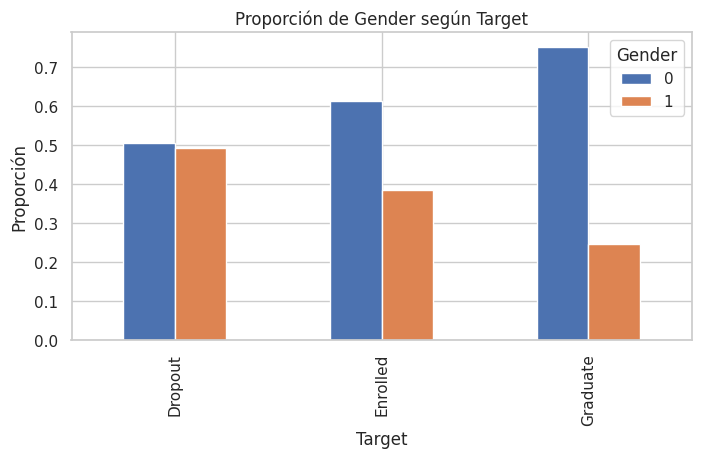

In [12]:
for col in cat_cols:
    tabla = pd.crosstab(df[col], df["Target"], normalize="columns")
    tabla.T.plot(kind="bar", figsize=(8, 4))
    plt.title(f"Proporción de {col} según Target")
    plt.ylabel("Proporción")
    plt.show()

Las variables financieras muestran diferencias importantes según el estado
final del estudiante. Los estudiantes graduados presentan mayor proporción de beca y de aranceles al día, mientras que los desertores concentran una mayor proporción de deudores. Esto sugiere que la situación económica podría influir en la permanencia y éxito académico.

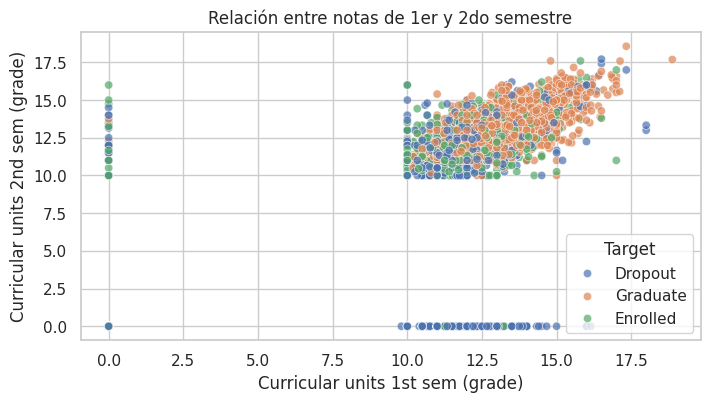

In [13]:
sns.scatterplot(
    data=df,
    x="Curricular units 1st sem (grade)",
    y="Curricular units 2nd sem (grade)",
    hue="Target",
    alpha=0.7
)
plt.title("Relación entre notas de 1er y 2do semestre")
plt.show()

Se observa una relación positiva entre las notas del primer y segundo semestre: en general, los estudiantes con mejor rendimiento en el primer semestre también tienden a obtener mejores notas en el segundo. Además, los estudiantes graduados se concentran más en valores altos en ambos semestres, mientras que los desertores presentan con mayor frecuencia notas bajas o nulas.

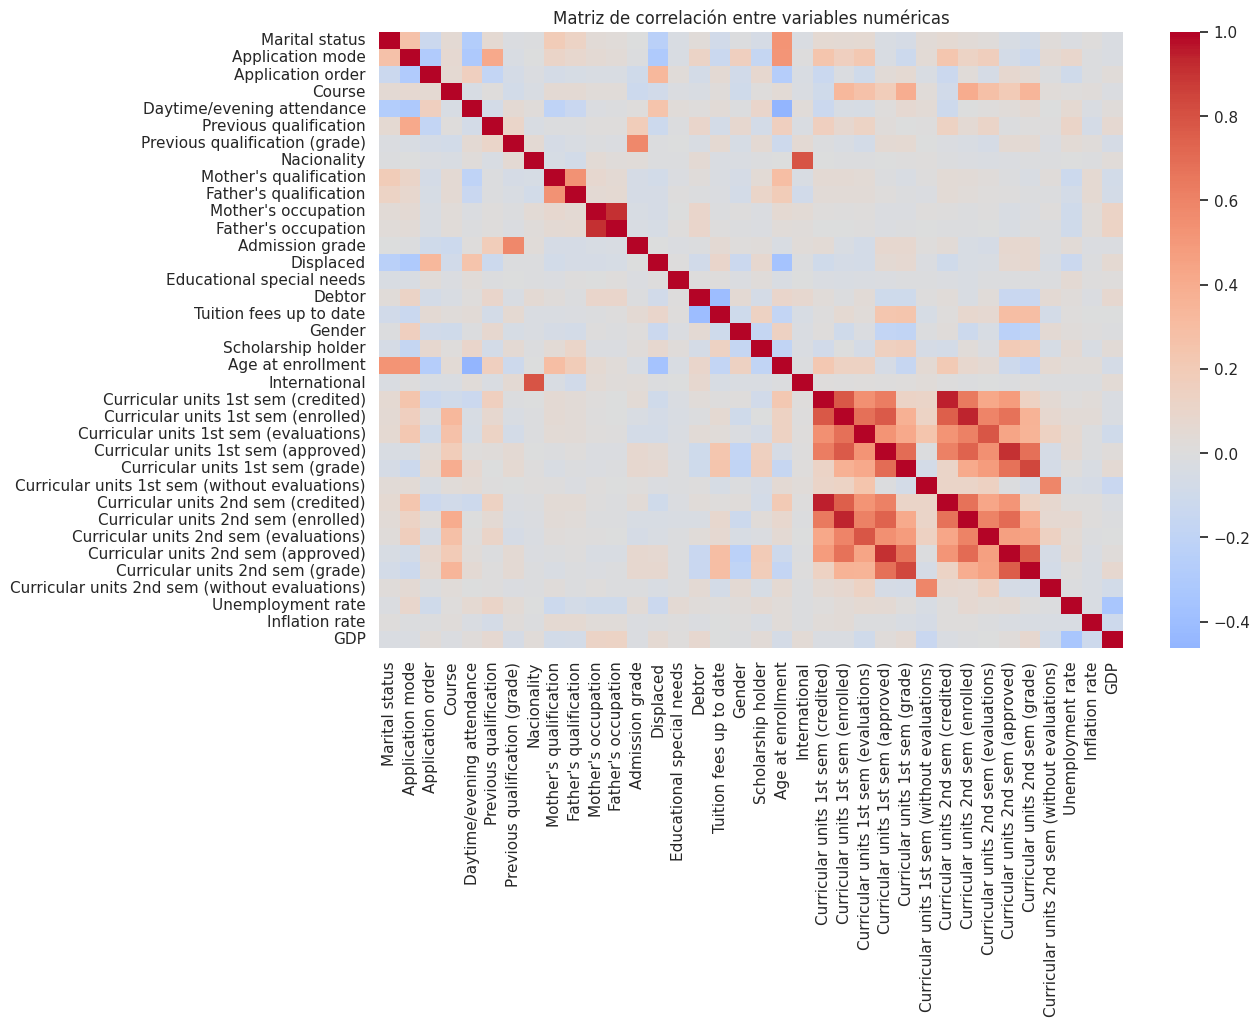

In [14]:
# Correlación entre variables numéricas
plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

La matriz de correlación muestra que las variables académicas del primer y segundo semestre presentan correlaciones positivas entre sí, especialmente las relacionadas con asignaturas aprobadas, evaluaciones y calificaciones.

### EDA

El análisis exploratorio permitió entender mejor la estructura y el comportamiento general del dataset. Se observó que el conjunto de datos está compuesto por 4424 registros y 37 variables, incluyendo la variable objetivo Target. Además, el dataset presenta una buena calidad inicial, ya que no contiene valores nulos ni filas duplicadas exactas.

En la variable objetivo se identificó un desbalance moderado, donde Graduate es la clase más frecuente, seguida por Dropout, mientras que Enrolled es la menos representada. Esto no impide trabajar con el dataset, pero sí es un aspecto que conviene considerar más adelante.

En las variables numéricas, las más relevantes fueron las relacionadas con el rendimiento académico. Tanto las notas como la cantidad de asignaturas aprobadas en el primer y segundo semestre mostraron diferencias claras entre los grupos. En general, los estudiantes Graduate presentan mejores resultados académicos, mientras que los Dropout concentran los valores más bajos. La categoría Enrolled tiende a ubicarse en un nivel intermedio.

También se observó que la edad al ingresar presenta cierta diferencia entre grupos, ya que los estudiantes que desertan tienden a matricularse con una edad algo mayor. En cambio, la calificación de admisión mostró diferencias menos marcadas que las variables académicas semestrales.

Por otro lado, algunas variables categóricas y binarias, especialmente las de tipo financiero, también mostraron patrones interesantes. Los estudiantes graduados presentan mayor proporción de aranceles al día y de beca, mientras que la condición de deudor aparece con mayor frecuencia en el grupo Dropout.

In [15]:
X = df.drop("Target", axis=1)
y = df["Target"]

print("Valores únicos de Mother's qualification:")
print(sorted(df["Mother's qualification"].unique()))

print("\nValores únicos de Father's qualification:")
print(sorted(df["Father's qualification"].unique()))

Valores únicos de Mother's qualification:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(18), np.int64(19), np.int64(22), np.int64(26), np.int64(27), np.int64(29), np.int64(30), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44)]

Valores únicos de Father's qualification:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(25), np.int64(26), np.int64(27), np.int64(29), np.int64(30), np.int64(31), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44)]


In [16]:
df[df["Father's qualification"] == 34].shape

(112, 37)

In [17]:
df[df["Mother's qualification"] == 34].shape

(130, 37)

### Mother's and Father's qualification

In [18]:
# Se agruparon los niveles educacionales de la madre y del padre en categorías más generales
# (Basica_o_menos, Secundaria, Tecnica, Universitaria, Postgrado y Desconocido)
# para reducir la granularidad original y facilitar el posterior One-Hot Encoding.

In [19]:
# Diccionarios de mapeo

mother_qualification_map = {
    # Básica o menos
    35: "Basica_o_menos",   # Can't read or write
    36: "Basica_o_menos",   # Can read without having a 4th year of schooling
    37: "Basica_o_menos",   # Basic education 1st cycle
    38: "Basica_o_menos",   # Basic education 2nd cycle

    # Secundaria
    1: "Secundaria",        # Secondary Education - 12th Year
    9: "Secundaria",        # 12th Year - not completed
    10: "Secundaria",       # 11th Year - not completed
    11: "Secundaria",       # 7th Year (Old)
    12: "Secundaria",       # Other - 11th Year
    14: "Secundaria",       # 10th Year
    19: "Secundaria",       # Basic education 3rd cycle
    26: "Secundaria",       # 7th year of schooling
    27: "Secundaria",       # 2nd cycle of the general high school course
    29: "Secundaria",       # 9th Year - not completed
    30: "Secundaria",       # 8th year of schooling

    # Técnica
    18: "Tecnica",          # General commerce course
    22: "Tecnica",          # Technical-professional course
    39: "Tecnica",          # Technological specialization course
    41: "Tecnica",          # Specialized higher studies course
    42: "Tecnica",          # Professional higher technical course

    # Universitaria
    2: "Universitaria",     # Bachelor's degree
    3: "Universitaria",     # Degree
    6: "Universitaria",     # Frequency of higher education
    40: "Universitaria",    # Higher education - degree (1st cycle)

    # Postgrado
    4: "Postgrado",         # Master's
    5: "Postgrado",         # Doctorate
    43: "Postgrado",        # Higher Education - Master (2nd cycle)
    44: "Postgrado",        # Higher Education - Doctorate (3rd cycle)

    # Desconocido
    34: "Desconocido"
}

father_qualification_map = {
    # Básica o menos
    35: "Basica_o_menos",
    36: "Basica_o_menos",
    37: "Basica_o_menos",
    38: "Basica_o_menos",

    # Secundaria
    1: "Secundaria",
    9: "Secundaria",
    10: "Secundaria",
    11: "Secundaria",
    12: "Secundaria",
    13: "Secundaria",       # 2nd year complementary high school course
    14: "Secundaria",
    19: "Secundaria",
    20: "Secundaria",       # Complementary High School Course
    25: "Secundaria",       # Complementary High School Course - not concluded
    26: "Secundaria",
    27: "Secundaria",
    29: "Secundaria",
    30: "Secundaria",

    # Técnica
    18: "Tecnica",
    22: "Tecnica",
    31: "Tecnica",          # General Course of Administration and Commerce
    33: "Tecnica",          # Supplementary Accounting and Administration
    39: "Tecnica",
    41: "Tecnica",
    42: "Tecnica",

    # Universitaria
    2: "Universitaria",
    3: "Universitaria",
    6: "Universitaria",
    40: "Universitaria",

    # Postgrado
    4: "Postgrado",
    5: "Postgrado",
    43: "Postgrado",
    44: "Postgrado",

    # Desconocido
    34: "Desconocido"
}

In [20]:
# 2. Crear nuevas columnas agrupadas

df["Mother_qualification_group"] = df["Mother's qualification"].map(mother_qualification_map)
df["Father_qualification_group"] = df["Father's qualification"].map(father_qualification_map)

In [21]:
# 3. Verificar resultados

print("Mother_qualification_group")
print(df["Mother_qualification_group"].value_counts(dropna=False))
print("\n")

print("Father_qualification_group")
print(df["Father_qualification_group"].value_counts(dropna=False))

Mother_qualification_group
Mother_qualification_group
Secundaria        2088
Basica_o_menos    1577
Universitaria      534
Desconocido        130
Postgrado           75
Tecnica             20
Name: count, dtype: int64


Father_qualification_group
Father_qualification_group
Secundaria        1944
Basica_o_menos    1921
Universitaria      357
Desconocido        112
Postgrado           60
Tecnica             30
Name: count, dtype: int64


In [22]:
# Revisar si quedó algún código sin mapear

print("Códigos sin mapear en Mother's qualification:")
print(df.loc[df["Mother_qualification_group"].isna(), "Mother's qualification"].unique())

print("\nCódigos sin mapear en Father's qualification:")
print(df.loc[df["Father_qualification_group"].isna(), "Father's qualification"].unique())

Códigos sin mapear en Mother's qualification:
[]

Códigos sin mapear en Father's qualification:
[]


In [23]:
# Ver algunas filas para comprobar

df[[
    "Mother's qualification",
    "Mother_qualification_group",
    "Father's qualification",
    "Father_qualification_group"
]].head(10)

,Mother's qualification,Mother_qualification_group,Father's qualification,Father_qualification_group
0,19,Secundaria,12,Secundaria
1,1,Secundaria,3,Universitaria
2,37,Basica_o_menos,37,Basica_o_menos
3,38,Basica_o_menos,37,Basica_o_menos
4,37,Basica_o_menos,38,Basica_o_menos
5,37,Basica_o_menos,37,Basica_o_menos
6,19,Secundaria,38,Basica_o_menos
7,37,Basica_o_menos,37,Basica_o_menos
8,1,Secundaria,1,Secundaria
9,1,Secundaria,19,Secundaria


### Previous qualification

In [24]:
# La variable 'Previous qualification' se agrupó en categorías más generales
# (Basica_o_menos, Secundaria, Tecnica, Universitaria y Postgrado)
# para simplificar su interpretación y facilitar el posterior One-Hot Encoding.

In [25]:
# 1. Diccionario de mapeo para Previous qualification

previous_qualification_map = {
    # Básica o menos
    19: "Basica_o_menos",   # Basic education 3rd cycle
    38: "Basica_o_menos",   # Basic education 2nd cycle

    # Secundaria
    1: "Secundaria",        # Secondary education
    9: "Secundaria",        # 12th year not completed
    10: "Secundaria",       # 11th year not completed
    12: "Secundaria",       # Other - 11th year
    14: "Secundaria",       # 10th year
    15: "Secundaria",       # 10th year not completed

    # Técnica
    39: "Tecnica",          # Technological specialization course
    42: "Tecnica",          # Professional higher technical course

    # Universitaria
    2: "Universitaria",     # Higher education - bachelor's degree
    3: "Universitaria",     # Higher education - degree
    6: "Universitaria",     # Frequency of higher education
    40: "Universitaria",    # Higher education - degree (1st cycle)

    # Postgrado
    4: "Postgrado",         # Higher education - master's
    5: "Postgrado",         # Higher education - doctorate
    43: "Postgrado"         # Higher education - master (2nd cycle)
}

In [26]:
# 2. Crear la nueva columna agrupada
df["Previous_qualification_group"] = df["Previous qualification"].map(previous_qualification_map)

In [27]:
# 3. Revisar cómo quedó

print(df["Previous_qualification_group"].value_counts(dropna=False))

Previous_qualification_group
Secundaria        3780
Tecnica            255
Universitaria      205
Basica_o_menos     169
Postgrado           15
Name: count, dtype: int64


In [28]:
# 4. Verificar si quedó algún código sin mapear

print("Códigos sin mapear en Previous qualification:")
print(df.loc[df["Previous_qualification_group"].isna(), "Previous qualification"].unique())

Códigos sin mapear en Previous qualification:
[]


In [29]:
# 5. Ver algunas filas de ejemplo

df[["Previous qualification", "Previous_qualification_group"]].head(10)

,Previous qualification,Previous_qualification_group
0,1,Secundaria
1,1,Secundaria
2,1,Secundaria
3,1,Secundaria
4,1,Secundaria
5,19,Basica_o_menos
6,1,Secundaria
7,1,Secundaria
8,1,Secundaria
9,1,Secundaria


In [36]:
# Las variables de ocupación de madre y padre se agruparon en categorías ocupacionales más amplias
# para reducir la cantidad de códigos originales y facilitar su interpretación.
# Esto también permite aplicar posteriormente One-Hot Encoding de forma más manejable.

In [30]:
print("Valores únicos de Mother's occupation:")
print(sorted(df["Mother's occupation"].unique()))

print("\nFrecuencias de Mother's occupation:")
print(df["Mother's occupation"].value_counts().sort_index())

print("\nValores únicos de Father's occupation:")
print(sorted(df["Father's occupation"].unique()))

print("\nFrecuencias de Father's occupation:")
print(df["Father's occupation"].value_counts().sort_index())

Valores únicos de Mother's occupation:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(90), np.int64(99), np.int64(122), np.int64(123), np.int64(125), np.int64(131), np.int64(132), np.int64(134), np.int64(141), np.int64(143), np.int64(144), np.int64(151), np.int64(152), np.int64(153), np.int64(171), np.int64(173), np.int64(175), np.int64(191), np.int64(192), np.int64(193), np.int64(194)]

Frecuencias de Mother's occupation:
Mother's occupation
0       144
1       102
2       318
3       351
4       817
5       530
6        91
7       272
8        36
9      1577
10        4
90       70
99       17
122       2
123       7
125       1
131       1
132       3
134       4
141       8
143       3
144       6
151       3
152       2
153       2
171       1
173       1
175       5
191      26
192       5
193       4
194      11
Name: count, dtype: int64

Valores únicos de Father's occupati

### Mother's occupation

In [31]:
# 1. Mapeo de Mother's occupation


mother_occupation_map = {
    0: "Estudiante",
    1: "Representantes_poder_publico_y_directivos",
    2: "Profesionales_y_tecnicos",
    3: "Tecnicos_y_profesionales_nivel_intermedio",
    4: "Administrativos_e_servicios",
    5: "Agricultura_y_oficios_calificados",
    6: "Operarios_y_montadores",
    7: "Trabajos_no_calificados",
    8: "Fuerzas_armadas",
    9: "Otra_situacion",
    10: "Otro_o_desconocido",
    90: "Otro_o_desconocido",
    99: "Otro_o_desconocido",

    122: "Profesionales_y_tecnicos",
    123: "Profesionales_y_tecnicos",
    125: "Profesionales_y_tecnicos",

    131: "Tecnicos_y_profesionales_nivel_intermedio",
    132: "Tecnicos_y_profesionales_nivel_intermedio",
    134: "Tecnicos_y_profesionales_nivel_intermedio",

    141: "Administrativos_e_servicios",
    143: "Administrativos_e_servicios",
    144: "Administrativos_e_servicios",

    151: "Administrativos_e_servicios",
    152: "Administrativos_e_servicios",
    153: "Administrativos_e_servicios",

    171: "Agricultura_y_oficios_calificados",
    173: "Agricultura_y_oficios_calificados",
    175: "Agricultura_y_oficios_calificados",

    191: "Operarios_y_montadores",
    192: "Operarios_y_montadores",
    193: "Operarios_y_montadores",
    194: "Operarios_y_montadores"
}

In [32]:
# 2. Mapeo de Father's occupation

father_occupation_map = {
    0: "Estudiante",
    1: "Representantes_poder_publico_y_directivos",
    2: "Profesionales_y_tecnicos",
    3: "Tecnicos_y_profesionales_nivel_intermedio",
    4: "Administrativos_e_servicios",
    5: "Agricultura_y_oficios_calificados",
    6: "Operarios_y_montadores",
    7: "Trabajos_no_calificados",
    8: "Fuerzas_armadas",
    9: "Otra_situacion",
    10: "Otro_o_desconocido",
    90: "Otro_o_desconocido",
    99: "Otro_o_desconocido",

    101: "Representantes_poder_publico_y_directivos",
    102: "Representantes_poder_publico_y_directivos",
    103: "Representantes_poder_publico_y_directivos",

    112: "Profesionales_y_tecnicos",
    114: "Profesionales_y_tecnicos",

    121: "Profesionales_y_tecnicos",
    122: "Profesionales_y_tecnicos",
    123: "Profesionales_y_tecnicos",
    124: "Profesionales_y_tecnicos",

    131: "Tecnicos_y_profesionales_nivel_intermedio",
    132: "Tecnicos_y_profesionales_nivel_intermedio",
    134: "Tecnicos_y_profesionales_nivel_intermedio",
    135: "Tecnicos_y_profesionales_nivel_intermedio",

    141: "Administrativos_e_servicios",
    143: "Administrativos_e_servicios",
    144: "Administrativos_e_servicios",

    151: "Administrativos_e_servicios",
    152: "Administrativos_e_servicios",
    153: "Administrativos_e_servicios",
    154: "Administrativos_e_servicios",

    161: "Agricultura_y_oficios_calificados",
    163: "Agricultura_y_oficios_calificados",

    171: "Operarios_y_montadores",
    172: "Operarios_y_montadores",
    174: "Operarios_y_montadores",
    175: "Operarios_y_montadores",

    181: "Operarios_y_montadores",
    182: "Operarios_y_montadores",
    183: "Operarios_y_montadores",

    192: "Trabajos_no_calificados",
    193: "Trabajos_no_calificados",
    194: "Trabajos_no_calificados",
    195: "Trabajos_no_calificados"
}

In [33]:
# 3. Crear nuevas columnas agrupadas

df["Mother_occupation_group"] = df["Mother's occupation"].map(mother_occupation_map)
df["Father_occupation_group"] = df["Father's occupation"].map(father_occupation_map)

In [34]:
# 4. Revisar cómo quedaron

print("Mother_occupation_group")
print(df["Mother_occupation_group"].value_counts(dropna=False))

print("\nFather_occupation_group")
print(df["Father_occupation_group"].value_counts(dropna=False))

Mother_occupation_group
Mother_occupation_group
Otra_situacion                               1577
Administrativos_e_servicios                   841
Agricultura_y_oficios_calificados             537
Tecnicos_y_profesionales_nivel_intermedio     359
Profesionales_y_tecnicos                      328
Trabajos_no_calificados                       272
Estudiante                                    144
Operarios_y_montadores                        137
Representantes_poder_publico_y_directivos     102
Otro_o_desconocido                             91
Fuerzas_armadas                                36
Name: count, dtype: int64

Father_occupation_group
Father_occupation_group
Otra_situacion                               1010
Trabajos_no_calificados                       690
Agricultura_y_oficios_calificados             522
Administrativos_e_servicios                   403
Tecnicos_y_profesionales_nivel_intermedio     390
Otro_o_desconocido                            350
Fuerzas_armadas            

In [35]:
# 5. Revisar si quedó algún código sin mapear

print("Códigos sin mapear en Mother's occupation:")
print(df.loc[df["Mother_occupation_group"].isna(), "Mother's occupation"].unique())

print("\nCódigos sin mapear en Father's occupation:")
print(df.loc[df["Father_occupation_group"].isna(), "Father's occupation"].unique())

Códigos sin mapear en Mother's occupation:
[]

Códigos sin mapear en Father's occupation:
[]


### Marital status

In [41]:
# La variable 'Marital status' se agrupó en tres categorías más generales
# para simplificar su interpretación y reducir la fragmentación de categorías
# antes de aplicar One-Hot Encoding.

In [37]:
# 1. Mapeo de Marital status

marital_status_map = {
    1: "Soltero",
    2: "Casado_o_union",
    5: "Casado_o_union",
    3: "Separado_divorciado_viudo",
    4: "Separado_divorciado_viudo",
    6: "Separado_divorciado_viudo"
}

In [38]:
# 2. Crear nueva columna agrupada

df["Marital_status_group"] = df["Marital status"].map(marital_status_map)

In [39]:
# 3. Revisar resultados

print(df["Marital_status_group"].value_counts(dropna=False))

Marital_status_group
Soltero                      3919
Casado_o_union                404
Separado_divorciado_viudo     101
Name: count, dtype: int64


In [40]:
# 4. Verificar si quedó algún código sin mapear

print("Códigos sin mapear en Marital status:")
print(df.loc[df["Marital_status_group"].isna(), "Marital status"].unique())

Códigos sin mapear en Marital status:
[]


### Aplication mode

In [ ]:
# Se recodificó la variable Aplication mode en grupos más amplios, ya que presentaba muchas categorías
# y varias de ellas tenían muy pocos registros. La reagrupación permitió reducir la
# fragmentación y mejorar la interpretabilidad sin perder el sentido general de la vía de ingreso.

In [48]:
# Diccionario de recodificación para Application mode
application_mode_map = {
    1: "Ingreso general",
    17: "Ingreso general",
    18: "Ingreso general",

    2: "Contingentes/normativas especiales",
    5: "Contingentes/normativas especiales",
    10: "Contingentes/normativas especiales",
    16: "Contingentes/normativas especiales",
    26: "Contingentes/normativas especiales",
    27: "Contingentes/normativas especiales",

    7: "Trayectoria previa en educación superior",
    44: "Trayectoria previa en educación superior",
    53: "Trayectoria previa en educación superior",

    42: "Cambio/transferencia",
    43: "Cambio/transferencia",
    51: "Cambio/transferencia",
    57: "Cambio/transferencia",

    39: "Mayores de 23",
    15: "Internacional"
}

# Crear nueva columna recodificada
df["Application mode grouped"] = df["Application mode"].map(application_mode_map)

# Revisar resultados
print(df[["Application mode", "Application mode grouped"]].head())

# Ver frecuencias de la nueva variable
print(df["Application mode grouped"].value_counts(dropna=False))

   Application mode Application mode grouped
0                17          Ingreso general
1                15            Internacional
2                 1          Ingreso general
3                17          Ingreso general
4                39            Mayores de 23
Application mode grouped
Ingreso general                             2704
Mayores de 23                                785
Cambio/transferencia                         449
Trayectoria previa en educación superior     387
Contingentes/normativas especiales            69
Internacional                                 30
Name: count, dtype: int64


In [49]:
# Revisar si hay códigos originales que no hayan sido incluidos en el diccionario
codigos_originales = sorted(df["Application mode"].unique())
codigos_mapeados = sorted(application_mode_map.keys())

faltantes = [codigo for codigo in codigos_originales if codigo not in codigos_mapeados]

print("Códigos faltantes en el mapeo:", faltantes)

Códigos faltantes en el mapeo: []


In [50]:
df["Application mode grouped"] = df["Application mode"].map(application_mode_map)

### Course

In [ ]:
# Se creó una versión agrupada de Course para explorar una representación más general
# por áreas académicas. Sin embargo, se decidió conservar también la variable original,
# ya que mantiene mayor nivel de detalle.

In [51]:
course_map = {
    9085: "Salud",
    9500: "Salud",
    9556: "Salud",

    9003: "Ciencias agrarias y animales",
    9130: "Ciencias agrarias y animales",

    9147: "Gestión, negocios y turismo",
    9991: "Gestión, negocios y turismo",
    9670: "Gestión, negocios y turismo",
    9254: "Gestión, negocios y turismo",

    8014: "Ciencias sociales y educación",
    9238: "Ciencias sociales y educación",
    9853: "Ciencias sociales y educación",

    171: "Comunicación y diseño",
    9070: "Comunicación y diseño",
    9773: "Comunicación y diseño",

    9119: "Tecnología e ingeniería",
    33: "Tecnología e ingeniería"
}

df["Course grouped"] = df["Course"].map(course_map)

In [52]:
print(df[["Course", "Course grouped"]].head())
print(df["Course grouped"].value_counts(dropna=False))

   Course                 Course grouped
0     171          Comunicación y diseño
1    9254    Gestión, negocios y turismo
2    9070          Comunicación y diseño
3    9773          Comunicación y diseño
4    8014  Ciencias sociales y educación
Course grouped
Salud                            1189
Gestión, negocios y turismo      1168
Comunicación y diseño             772
Ciencias sociales y educación     762
Ciencias agrarias y animales      351
Tecnología e ingeniería           182
Name: count, dtype: int64


In [ ]:
# Se detectó un valor anómalo igual a 0 en Application order, lo cual es inconsistente
# con la lógica de la variable, ya que el orden esperado comienza en 1. Este valor se trató
# como faltante y posteriormente se imputó con la moda por corresponder a un único caso aislado.

In [53]:
df.loc[df["Application order"] == 0, "Application order"] = pd.NA

In [ ]:
# 0 a missing

In [54]:
print(df["Application order"].value_counts(dropna=False).sort_index())

Application order
1.0    3026
2.0     547
3.0     309
4.0     249
5.0     154
6.0     137
9.0       1
NaN       1
Name: count, dtype: int64


In [ ]:
# Se eliminó Nacionality, ya que su información quedaba prácticamente contenida en International.
# De este modo, se evitó duplicar información y se conservó la variable más simple de interpretar.

In [56]:
# Coincidencia de Nationality y International
pd.crosstab(df["Nacionality"], df["International"])

International,0,1
Nacionality,,
1,4314,0
2,0,2
6,0,13
11,0,3
13,0,1
14,0,1
17,0,1
21,0,2
22,0,13


In [63]:
# Eliminar Nacionality ya está muy correlacionada con International
# df = df.drop(columns=["Nacionality"])

In [65]:
# Verificar redundancia de Daytime/evening attendance con Course
pd.crosstab(df["Course"], df["Daytime/evening attendance"])

Daytime/evening attendance,0,1
Course,,
33,0,12
171,0,215
8014,215,0
9003,0,210
9070,0,226
9085,0,337
9119,0,170
9130,0,141
9147,0,380


In [66]:
# Verificar desbalance de variable Educational special needs
print(df["Educational special needs"].value_counts(dropna=False))
print(df["Educational special needs"].value_counts(normalize=True, dropna=False) * 100)

Educational special needs
0    4373
1      51
Name: count, dtype: int64
Educational special needs
0    98.847197
1     1.152803
Name: proportion, dtype: float64


In [67]:
# Verificar desbalance de variable de Deptor
print(df["Debtor"].value_counts(dropna=False))
print(df["Debtor"].value_counts(normalize=True, dropna=False) * 100)

Debtor
0    3921
1     503
Name: count, dtype: int64
Debtor
0    88.630199
1    11.369801
Name: proportion, dtype: float64


In [68]:
# Relación con elación con Tuition fees up to date
pd.crosstab(df["Debtor"], df["Tuition fees up to date"])

Tuition fees up to date,0,1
Debtor,,
0,282,3639
1,246,257


In [70]:
print(df["Scholarship holder"].value_counts(dropna=False))
print(df["Scholarship holder"].value_counts(normalize=True, dropna=False) * 100)

Scholarship holder
0    3325
1    1099
Name: count, dtype: int64
Scholarship holder
0    75.158228
1    24.841772
Name: proportion, dtype: float64


In [71]:
for col in ["Displaced", "Gender", "Tuition fees up to date"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print(df[col].value_counts(normalize=True, dropna=False) * 100)


--- Displaced ---
Displaced
1    2426
0    1998
Name: count, dtype: int64
Displaced
1    54.837251
0    45.162749
Name: proportion, dtype: float64

--- Gender ---
Gender
0    2868
1    1556
Name: count, dtype: int64
Gender
0    64.82821
1    35.17179
Name: proportion, dtype: float64

--- Tuition fees up to date ---
Tuition fees up to date
1    3896
0     528
Name: count, dtype: int64
Tuition fees up to date
1    88.065099
0    11.934901
Name: proportion, dtype: float64


In [72]:
print(df.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target', 'Mother_qualification_group'

In [73]:
# Copia del dataframe original
df_model = df.copy()

# Columnas a eliminar del dataset de modelado
columns_to_drop = [
    "Marital status",
    "Application mode",
    "Daytime/evening attendance",
    "Previous qualification",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Nacionality_group",
    "Course grouped"
]

# Eliminar columnas
df_model = df_model.drop(columns=columns_to_drop)

In [74]:
# Columnas categóricas que sí irán con one-hot encoding
categorical_cols = [
    "Marital_status_group",
    "Application mode grouped",
    "Previous_qualification_group",
    "Mother_qualification_group",
    "Father_qualification_group",
    "Mother_occupation_group",
    "Father_occupation_group",
    "Course"
]

# Aplicar one-hot encoding
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=False)

# Revisar resultado
print("Dimensión final:", df_model.shape)
print("\nPrimeras columnas:")
print(df_model.columns.tolist()[:30])

Dimensión final: (4424, 92)

Primeras columnas:
['Application order', 'Previous qualification (grade)', 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target', 'Marital_status_group_Casado_o_union', 'Marital_status_group_Separado_divorciado_viudo', 'Marital_status_group_Soltero']


In [75]:
print(df_model.columns.tolist())

['Application order', 'Previous qualification (grade)', 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target', 'Marital_status_group_Casado_o_union', 'Marital_status_group_Separado_divorciado_viudo', 'Marital_status_group_Soltero', 'Application mode grouped_Cambio/transferencia', 'Application mode grouped_Contingentes/normativas especiales

In [76]:
print("Target" in df_model.columns)

True


In [77]:
print(df_model.isna().sum()[df_model.isna().sum() > 0])

Application order    1
dtype: int64


In [79]:
# Imputar valor nulo de Application order
df_model["Application order"] = df_model["Application order"].fillna(df_model["Application order"].mode()[0])

### Preprocesamiento de datos

En esta etapa se realizó un preprocesamiento del dataset con el objetivo de dejar los datos en condiciones adecuadas para etapas posteriores del análisis. Para ello, se revisaron las variables disponibles, se detectaron inconsistencias, se redujo la fragmentación de categorías, se eliminaron redundancias y se codificaron las variables categóricas de forma apropiada.

En primer lugar, se identificaron varias variables categóricas que presentaban una gran cantidad de categorías, muchas de ellas con frecuencias muy bajas. Esto ocurría especialmente en variables como Mother's qualification, Father's qualification, Previous qualification, Mother's occupation, Father's occupation, Marital status y Application mode. En estos casos se realizó una reagrupación de categorías, uniendo niveles conceptualmente similares o poco frecuentes en grupos más amplios y más interpretables. Esta decisión permitió reducir la dispersión de categorías y facilitar el tratamiento posterior de estas variables.

También se evaluó la posible redundancia entre variables. Se detectó que Nacionality entregaba, en la práctica, la misma información que International, por lo que se decidió conservar esta última y eliminar la primera. De forma similar, Daytime/evening attendance presentaba una relación completamente determinada por Course, ya que ciertas carreras aparecían exclusivamente en una única modalidad horaria. Debido a esto, esta variable no fue considerada en el conjunto final para modelado, evitando duplicar información.

Posteriormente, se revisaron posibles inconsistencias en los valores. En la variable Application order, que representa el orden de preferencia de postulación, se encontró un registro con valor 0, lo que se consideró anómalo, ya que el orden esperado comienza en 1. Este valor fue tratado inicialmente como faltante. Dado que se trataba de un único caso y que la variable es de carácter ordinal, se decidió imputarlo usando la moda de la variable, ya que esta opción permite conservar el registro sin introducir una alteración significativa en la distribución general de los datos.

Una vez finalizada la limpieza, se construyó un dataset de trabajo en el que se conservaron las variables numéricas, las variables binarias y las versiones reagrupadas de las variables categóricas. Las versiones originales de las variables ya recodificadas fueron excluidas del conjunto final para evitar redundancia y asegurar una estructura más clara.

Finalmente, se aplicó one-hot encoding a las variables categóricas nominales seleccionadas, generando columnas binarias para representar cada categoría sin imponer un orden artificial entre ellas. En cambio, las variables binarias se mantuvieron en formato 0/1, y las variables numéricas y ordinales conservaron su estructura original.